In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/combined_eeg_features.csv


Epoch 1/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.4896 - loss: 24.5568 - val_accuracy: 0.7295 - val_loss: 22.3759
Epoch 2/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7614 - loss: 21.7318 - val_accuracy: 0.7803 - val_loss: 19.9038
Epoch 3/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8101 - loss: 19.3108 - val_accuracy: 0.8098 - val_loss: 17.7297
Epoch 4/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8684 - loss: 17.1688 - val_accuracy: 0.8311 - val_loss: 15.8206
Epoch 5/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8881 - loss: 15.3127 - val_accuracy: 0.8344 - val_loss: 14.1350
Epoch 6/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9106 - loss: 13.6585 - val_accuracy: 0.8377 - val_loss: 12.6662
Epoch 7/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9122 - loss: 12.2155 - val_accuracy: 0.8492 - val_loss: 11.3615
Epoch 8/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9296 - loss: 10.9307 - v

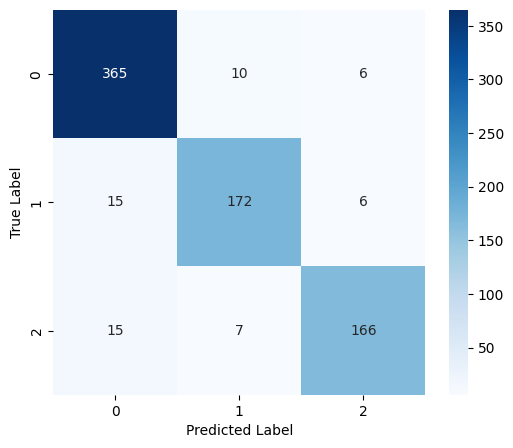

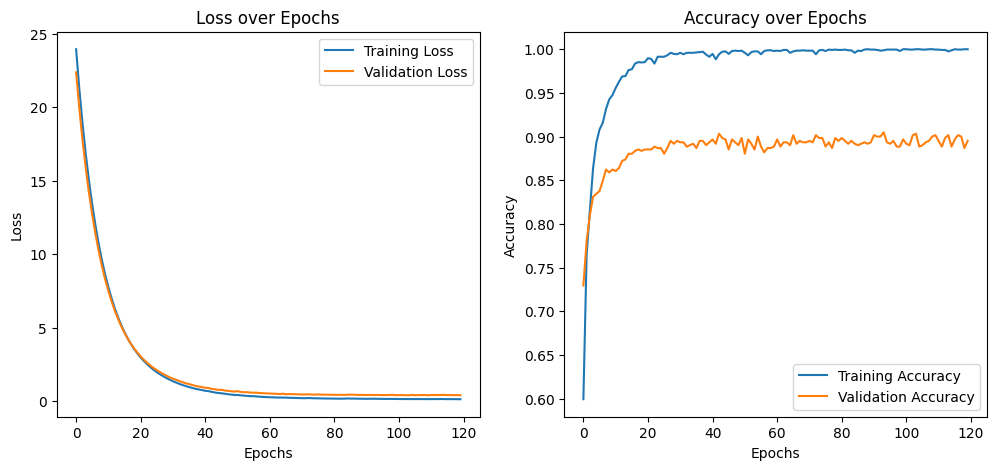

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Bidirectional, LSTM, GRU, Dropout, Lambda
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import classification_report


dataset_path = "/kaggle/input/combined_eeg_features.csv"
df = pd.read_csv(dataset_path, header=None)

X = df.iloc[:, :-1].values 
y = df.iloc[:, -1].values  

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, shuffle=True, random_state=42
)

num_classes = len(np.unique(y))
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

def build_model(input_shape, num_classes):
    inputs = Input(shape=(input_shape,))
    
    x = Lambda(lambda t: tf.expand_dims(t, axis=1))(inputs)
    
    x = Bidirectional(LSTM(128, return_sequences=True, kernel_regularizer=l2(0.01)))(x)
    
    x = Bidirectional(GRU(128, return_sequences=False, kernel_regularizer=l2(0.01)))(x)
    
    x = Dropout(0.2)(x)
    
    outputs = Dense(num_classes, activation="softmax")(x)
    
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model

model = build_model(X_train.shape[1], num_classes)
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(X_train, y_train,
                    validation_split=0.2,
                    epochs=250,
                    batch_size=128,
                    callbacks=[early_stopping],
                    verbose=1)

y_train_pred = np.argmax(model.predict(X_train), axis=1)
y_test_pred = np.argmax(model.predict(X_test), axis=1)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")


print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred, digits=4))

conf_matrix = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues",
            xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.show()

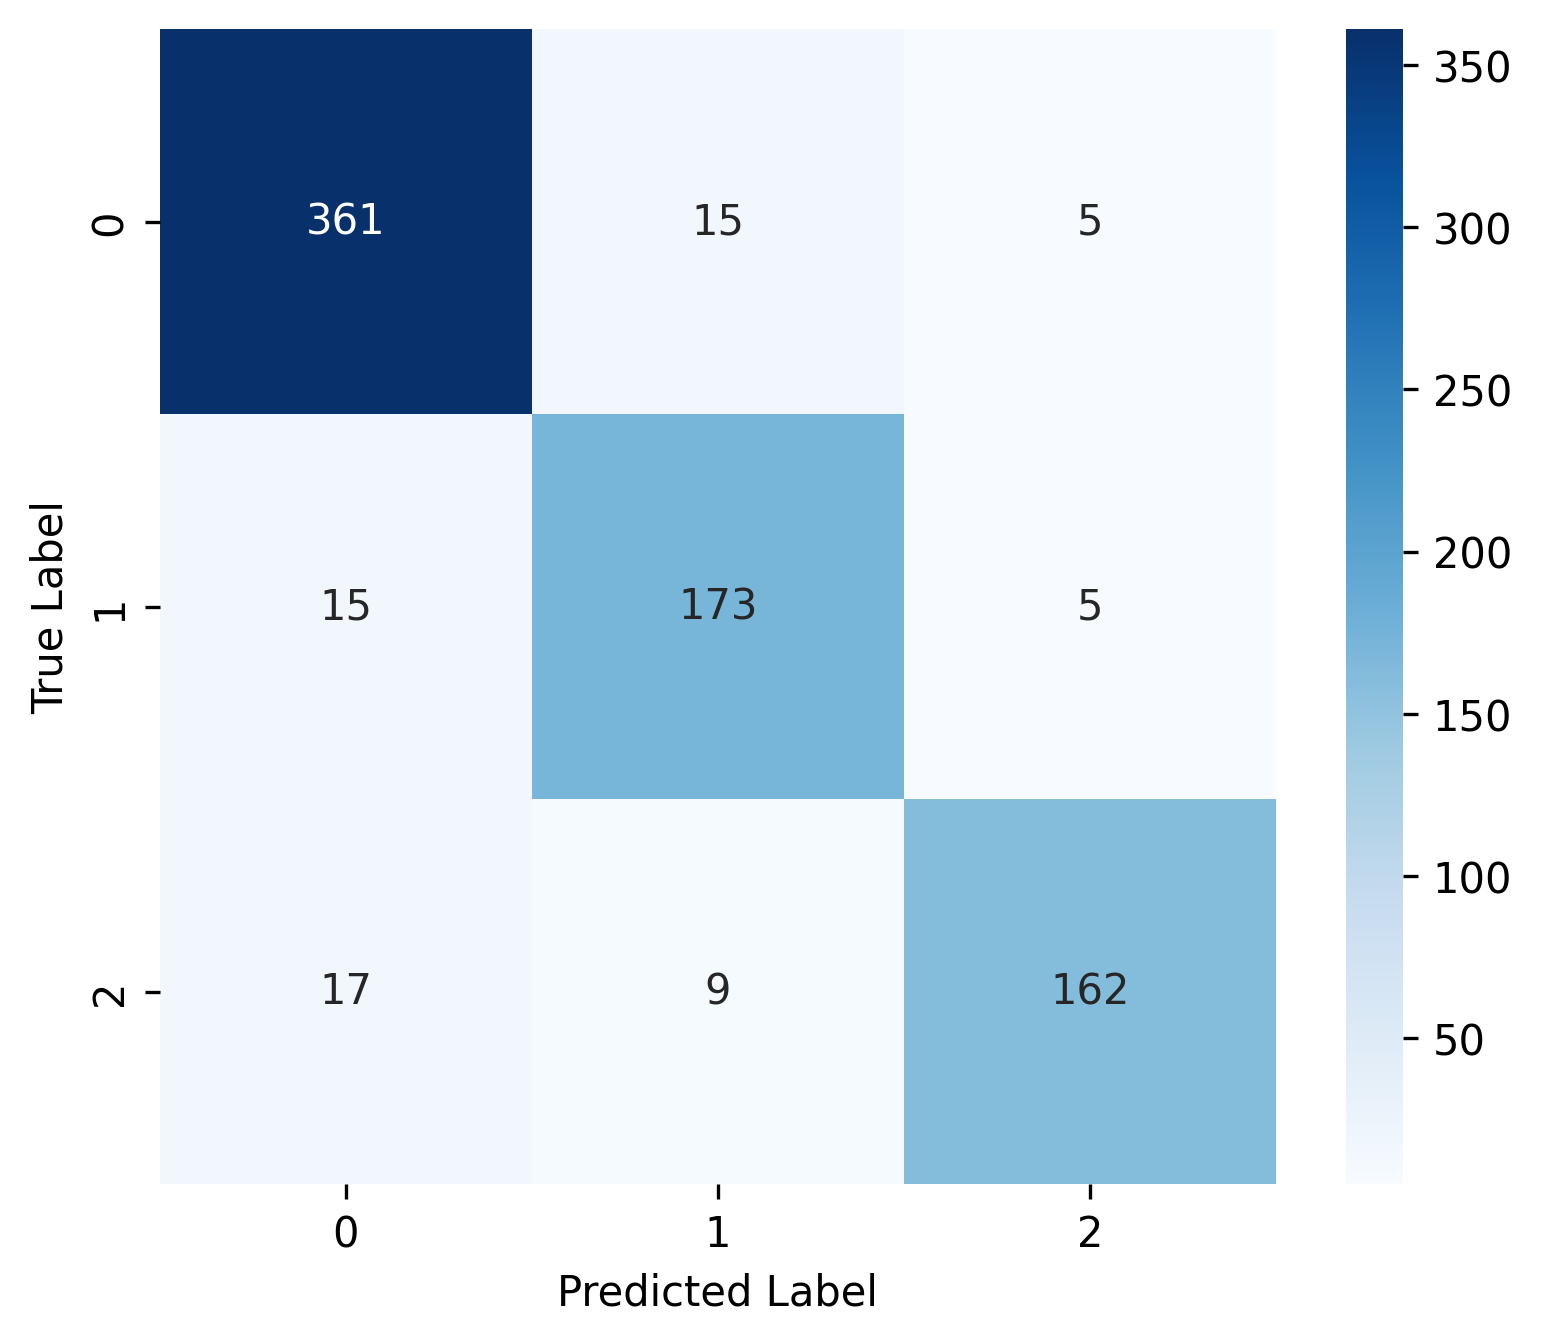

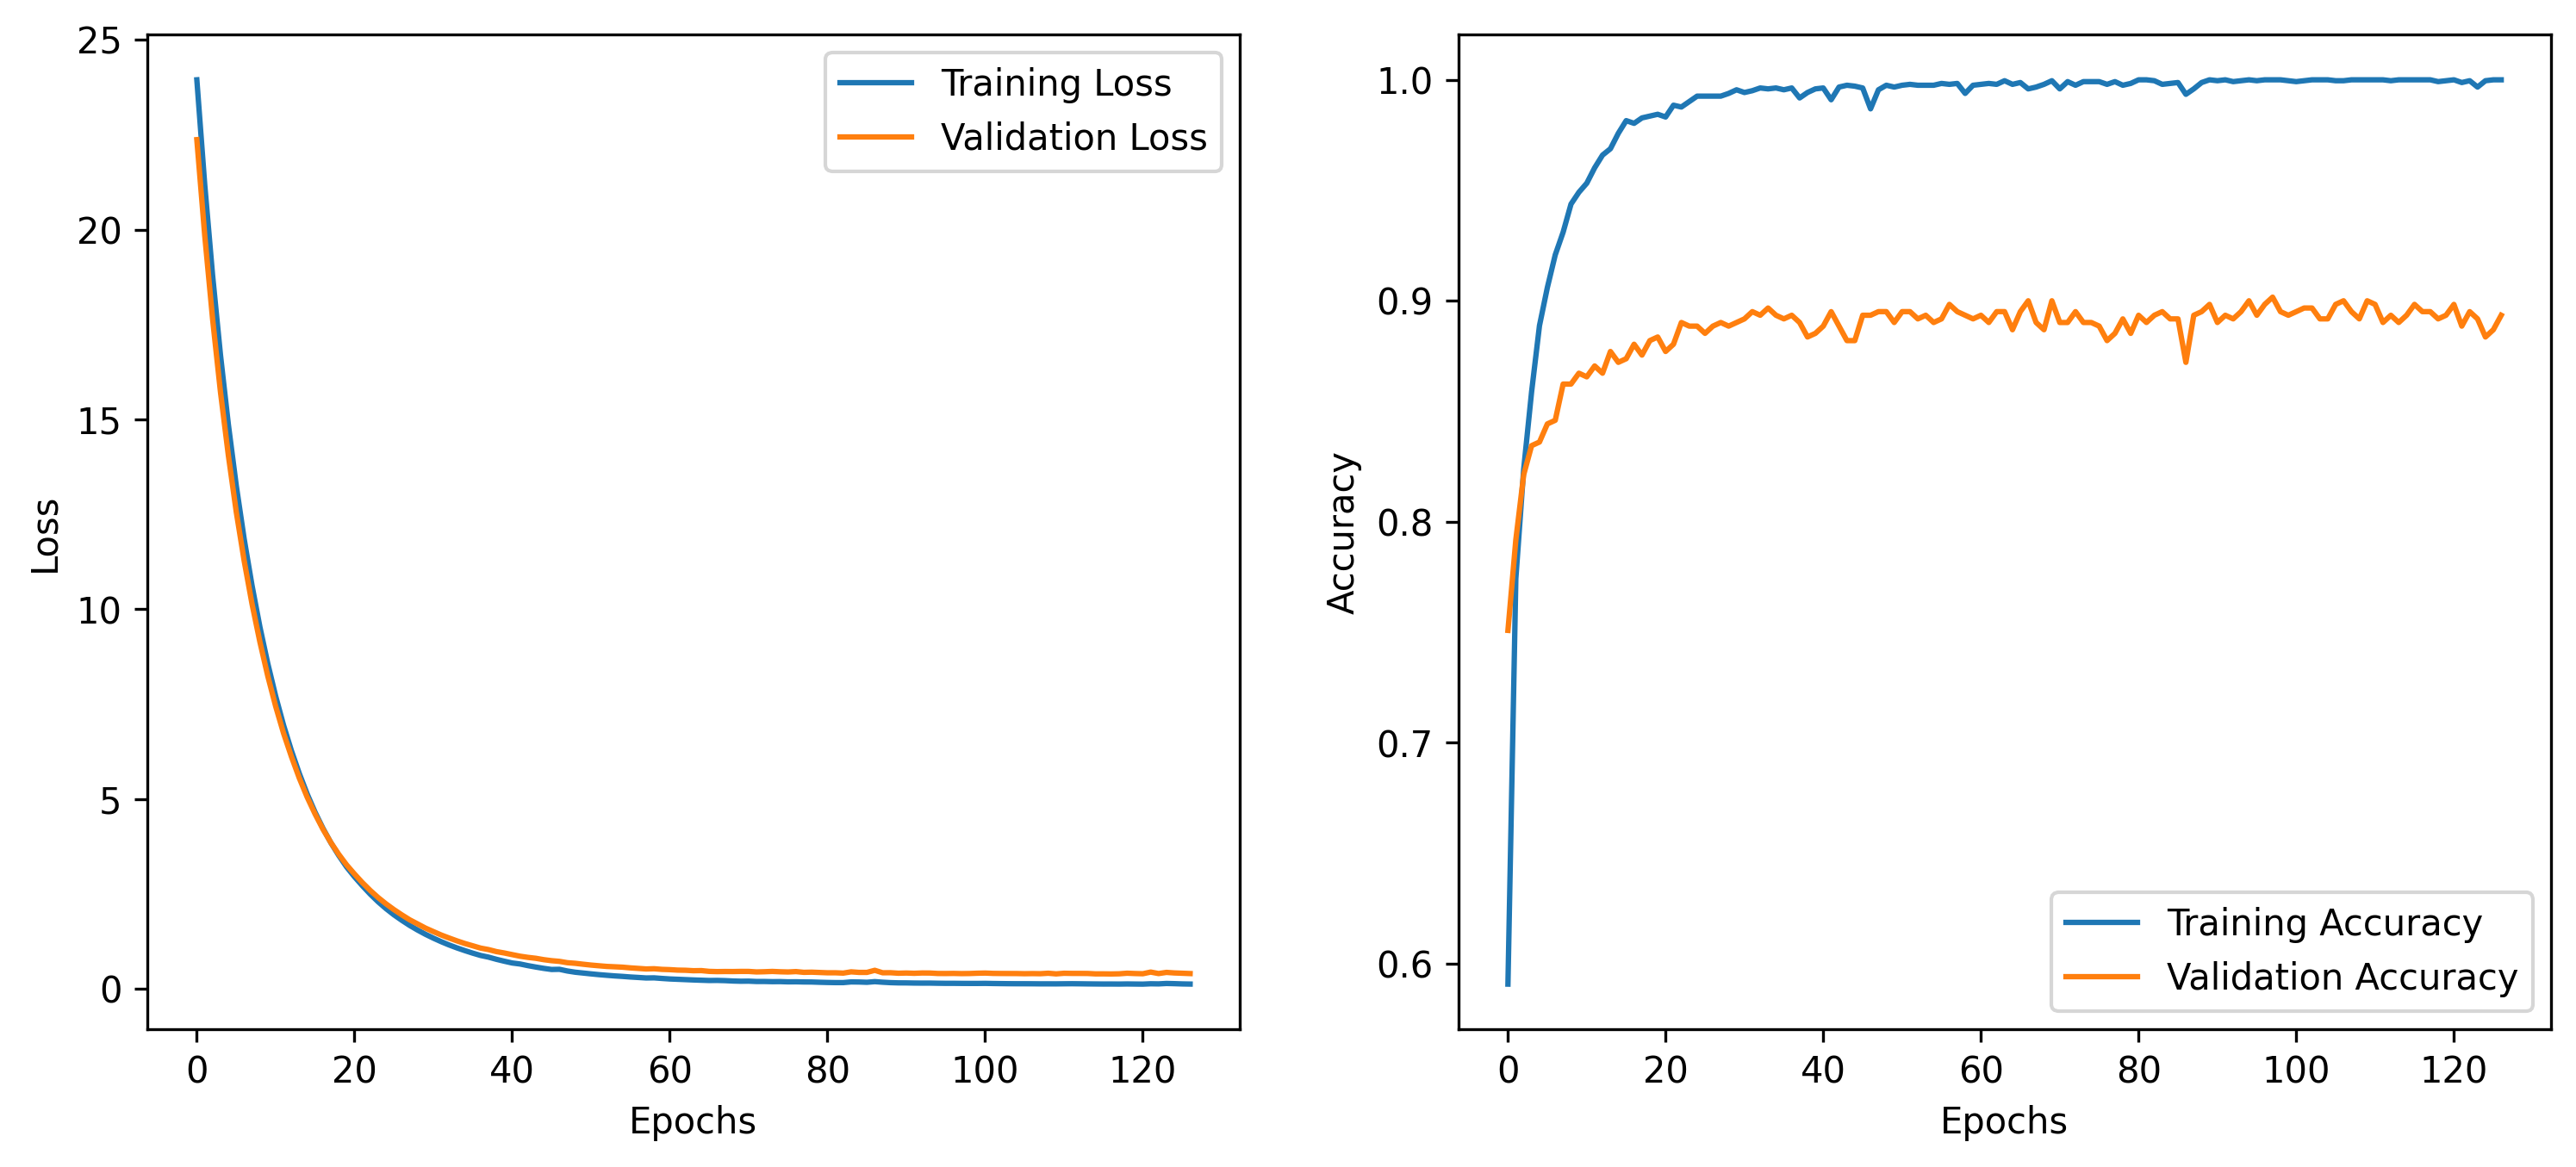

In [10]:
conf_matrix = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6,5), dpi=300)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues",
            xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


plt.figure(figsize=(12,5), dpi=300)

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

CV for BiLSTM-BiGRU

In [1]:
from sklearn.model_selection import StratifiedKFold
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Bidirectional, LSTM, GRU, Dropout, Lambda
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.utils import to_categorical


dataset_path = "/kaggle/input/eeg-motor-v1/combined_eeg_features.csv"
df = pd.read_csv(dataset_path, header=None)

X = df.iloc[:, :-1].values  
y = df.iloc[:, -1].values  

scaler = StandardScaler()
X = scaler.fit_transform(X)

num_classes = len(np.unique(y))

K = 10

skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)

train_accuracies = []
test_accuracies = []
history_list = []

def build_model(input_shape, num_classes):
    inputs = Input(shape=(input_shape,))
    
    x = Lambda(lambda t: tf.expand_dims(t, axis=1))(inputs)
    
    x = Bidirectional(LSTM(128, return_sequences=True, kernel_regularizer=l2(0.01)))(x)
    
    x = Bidirectional(GRU(128, return_sequences=False, kernel_regularizer=l2(0.01)))(x)
    
    x = Dropout(0.2)(x)
    
    outputs = Dense(num_classes, activation="softmax")(x)
    
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(learning_rate=1e-4),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model

K = 10

skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)

train_accuracies = []
test_accuracies = []
history_list = []  

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    print(f"\nTraining on Fold {fold + 1}/{K}...\n")
    
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    y_train_cat = to_categorical(y_train, num_classes)
    y_test_cat = to_categorical(y_test, num_classes)

    model = build_model(X_train.shape[1], num_classes)

    early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=250,
        batch_size=128,
        callbacks=[early_stopping],
        verbose=0
    )

    history_list.append(history.history)

    y_train_pred = np.argmax(model.predict(X_train), axis=1)
    y_test_pred = np.argmax(model.predict(X_test), axis=1)

    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    print(f"Fold {fold + 1} - Training Accuracy: {train_accuracy:.4f}")
    print(f"Fold {fold + 1} - Testing Accuracy: {test_accuracy:.4f}")

    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

mean_train_accuracy = np.mean(train_accuracies)
mean_test_accuracy = np.mean(test_accuracies)

print("\n----------------------")
print(f"Mean Training Accuracy: {mean_train_accuracy:.4f}")
print(f"Mean Testing Accuracy: {mean_test_accuracy:.4f}")
print("----------------------")


Training on Fold 1/10...

108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Fold 1 - Training Accuracy: 0.9758
Fold 1 - Testing Accuracy: 0.9108

Training on Fold 2/10...

108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Fold 2 - Training Accuracy: 0.9769
Fold 2 - Testing Accuracy: 0.8871

Training on Fold 3/10...

108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Fold 3 - Training Accuracy: 0.9761
Fold 3 - Testing Accuracy: 0.9239

Training on Fold 4/10...

108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Fold 4 - Training Accuracy: 0.9740
Fold 4 - Testing Accuracy: 0.9029

Training on Fold 5/10...

108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Fold 5 - Training Accuracy: 0.9761
Fold 5 - Testing Accuracy: 0.8871

Training on Fold 6/10...

108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Fold 6 

In [5]:
from sklearn.model_selection import StratifiedKFold
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Bidirectional, LSTM, GRU, Dropout, Lambda
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from tensorflow.keras.utils import to_categorical

dataset_path = "/kaggle/input/combined_eeg_features.csv"
df = pd.read_csv(dataset_path, header=None)

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

num_classes = len(np.unique(y))

K = 10 

skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=123)

train_accuracies = []
test_accuracies = []
history_list = []  

def build_model(input_shape, num_classes):
    inputs = Input(shape=(input_shape,))
    
    x = Lambda(lambda t: tf.expand_dims(t, axis=1))(inputs)
    
    x = Bidirectional(LSTM(128, return_sequences=True, kernel_regularizer=l2(0.01)))(x)
    
    x = Bidirectional(GRU(128, return_sequences=False, kernel_regularizer=l2(0.01)))(x)
    
    x = Dropout(0.2)(x)
    
    outputs = Dense(num_classes, activation="softmax")(x)
    
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(learning_rate=1e-4),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    print(f"\nTraining on Fold {fold + 1}/{K}...\n")
    
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = build_model(X_train.shape[1], num_classes)

    early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=250,
        batch_size=128,
        callbacks=[early_stopping],
        verbose=0 
    )

    history_list.append(history.history)

    y_train_pred = np.argmax(model.predict(X_train), axis=1)
    y_test_pred = np.argmax(model.predict(X_test), axis=1)

    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    print(f"Fold {fold + 1} - Training Accuracy: {train_accuracy:.4f}")
    print(f"Fold {fold + 1} - Testing Accuracy: {test_accuracy:.4f}")

    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

mean_train_accuracy = np.mean(train_accuracies)
std_train_accuracy = np.std(train_accuracies)

mean_test_accuracy = np.mean(test_accuracies)
std_test_accuracy = np.std(test_accuracies)

print("\n----------------------")
print(f"Mean Training Accuracy: {mean_train_accuracy:.4f} ± {std_train_accuracy:.4f}")
print(f"Mean Testing Accuracy: {mean_test_accuracy:.4f} ± {std_test_accuracy:.4f}")
print("----------------------")



Training on Fold 1/10...

108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Fold 1 - Training Accuracy: 0.9758
Fold 1 - Testing Accuracy: 0.8793

Training on Fold 2/10...

108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Fold 2 - Training Accuracy: 0.9775
Fold 2 - Testing Accuracy: 0.9055

Training on Fold 3/10...

108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Fold 3 - Training Accuracy: 0.9775
Fold 3 - Testing Accuracy: 0.8766

Training on Fold 4/10...

108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Fold 4 - Training Accuracy: 0.9752
Fold 4 - Testing Accuracy: 0.9134

Training on Fold 5/10...

108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Fold 5 - Training Accuracy: 0.9787
Fold 5 - Testing Accuracy: 0.9081

Training on Fold 6/10...

108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Fold 6 

Transformer-based: https://www.nature.com/articles/s41598-023-41653-w

2025-04-27 02:11:33.285829: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745719893.478923      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745719893.534857      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
I0000 00:00:1745719908.824774      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
/usr/local/lib/python3.11/dist-packages/keras/src/ops/nn.py:545: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 2, 1, 1). This axis has size 1. The softmax operation will alw

Epoch 1/500


I0000 00:00:1745719919.314097      92 service.cc:148] XLA service 0x7893a420f110 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745719919.314871      92 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1745719920.153719      92 cuda_dnn.cc:529] Loaded cuDNN version 90300


15/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3842 - loss: 13.8955  

I0000 00:00:1745719924.196340      92 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 325ms/step - accuracy: 0.3977 - loss: 13.8182 - val_accuracy: 0.6262 - val_loss: 12.8140
Epoch 2/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5274 - loss: 13.1894 - val_accuracy: 0.6984 - val_loss: 12.4647
Epoch 3/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5666 - loss: 12.8652 - val_accuracy: 0.7443 - val_loss: 12.1876
Epoch 4/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6017 - loss: 12.5852 - val_accuracy: 0.7590 - val_loss: 11.9459
Epoch 5/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6386 - loss: 12.2951 - val_accuracy: 0.7885 - val_loss: 11.7157
Epoch 6/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6546 - loss: 12.0810 - val_accuracy: 0.8049 - val_loss: 11.5113
Epoch 7/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6711 - loss: 11.8176 - val_accuracy: 0.8131 - val_loss: 11.3281
Epoch 8/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6919 - loss: 11.6526 - val_accuracy: 0.81

/usr/local/lib/python3.11/dist-packages/keras/src/ops/nn.py:545: UserWarning: You are using a softmax over axis 3 of a tensor of shape (32, 2, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
Training Accuracy: 0.9757
Testing Accuracy: 0.8766

Classification Report (Test Set):
              precision    recall  f1-score   support

         0.0     0.9060    0.9108    0.9084       381
         1.0     0.8267    0.8653    0.8456       193
         2.0     0.8701    0.8191    0.8438       188

    accuracy                         0.8766       762
   macro avg     0.8676    0.8651    0.8659       762
weighted avg     0.8771    0.8766    0.8765       762



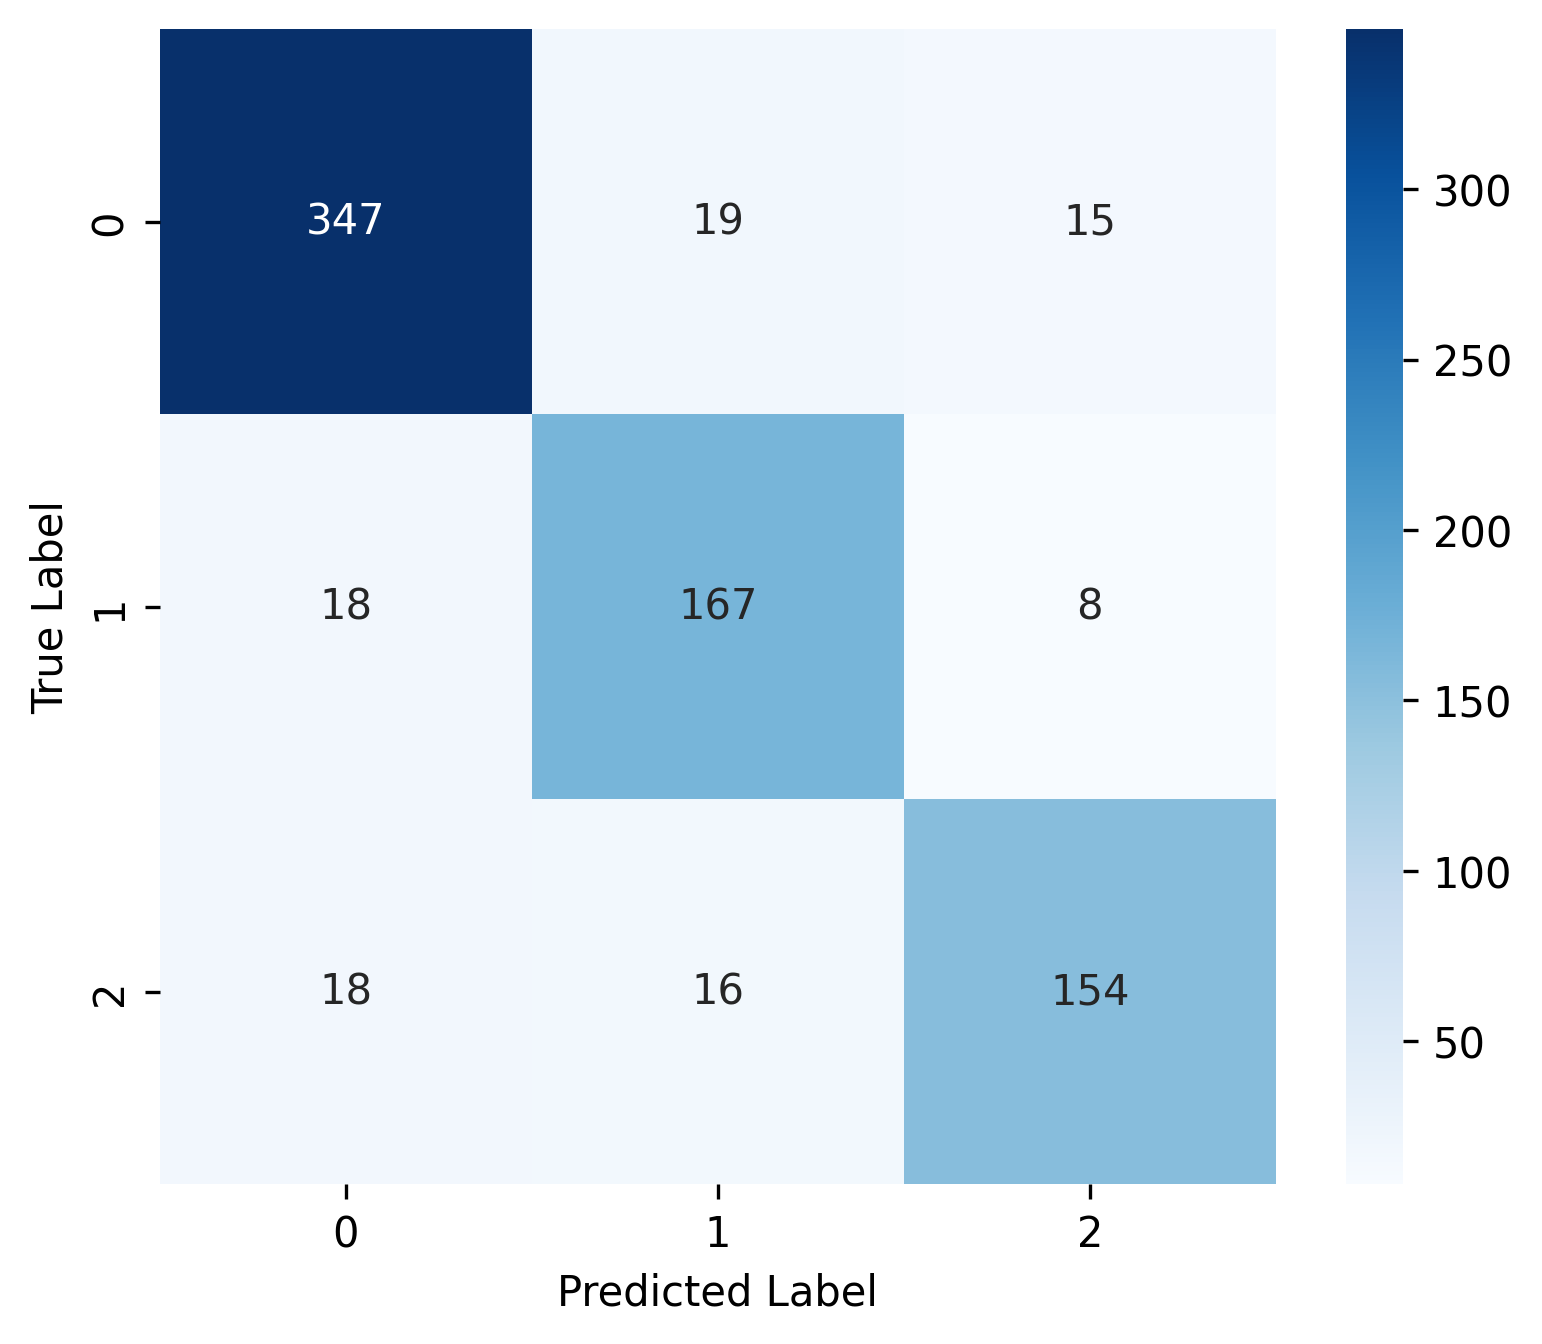

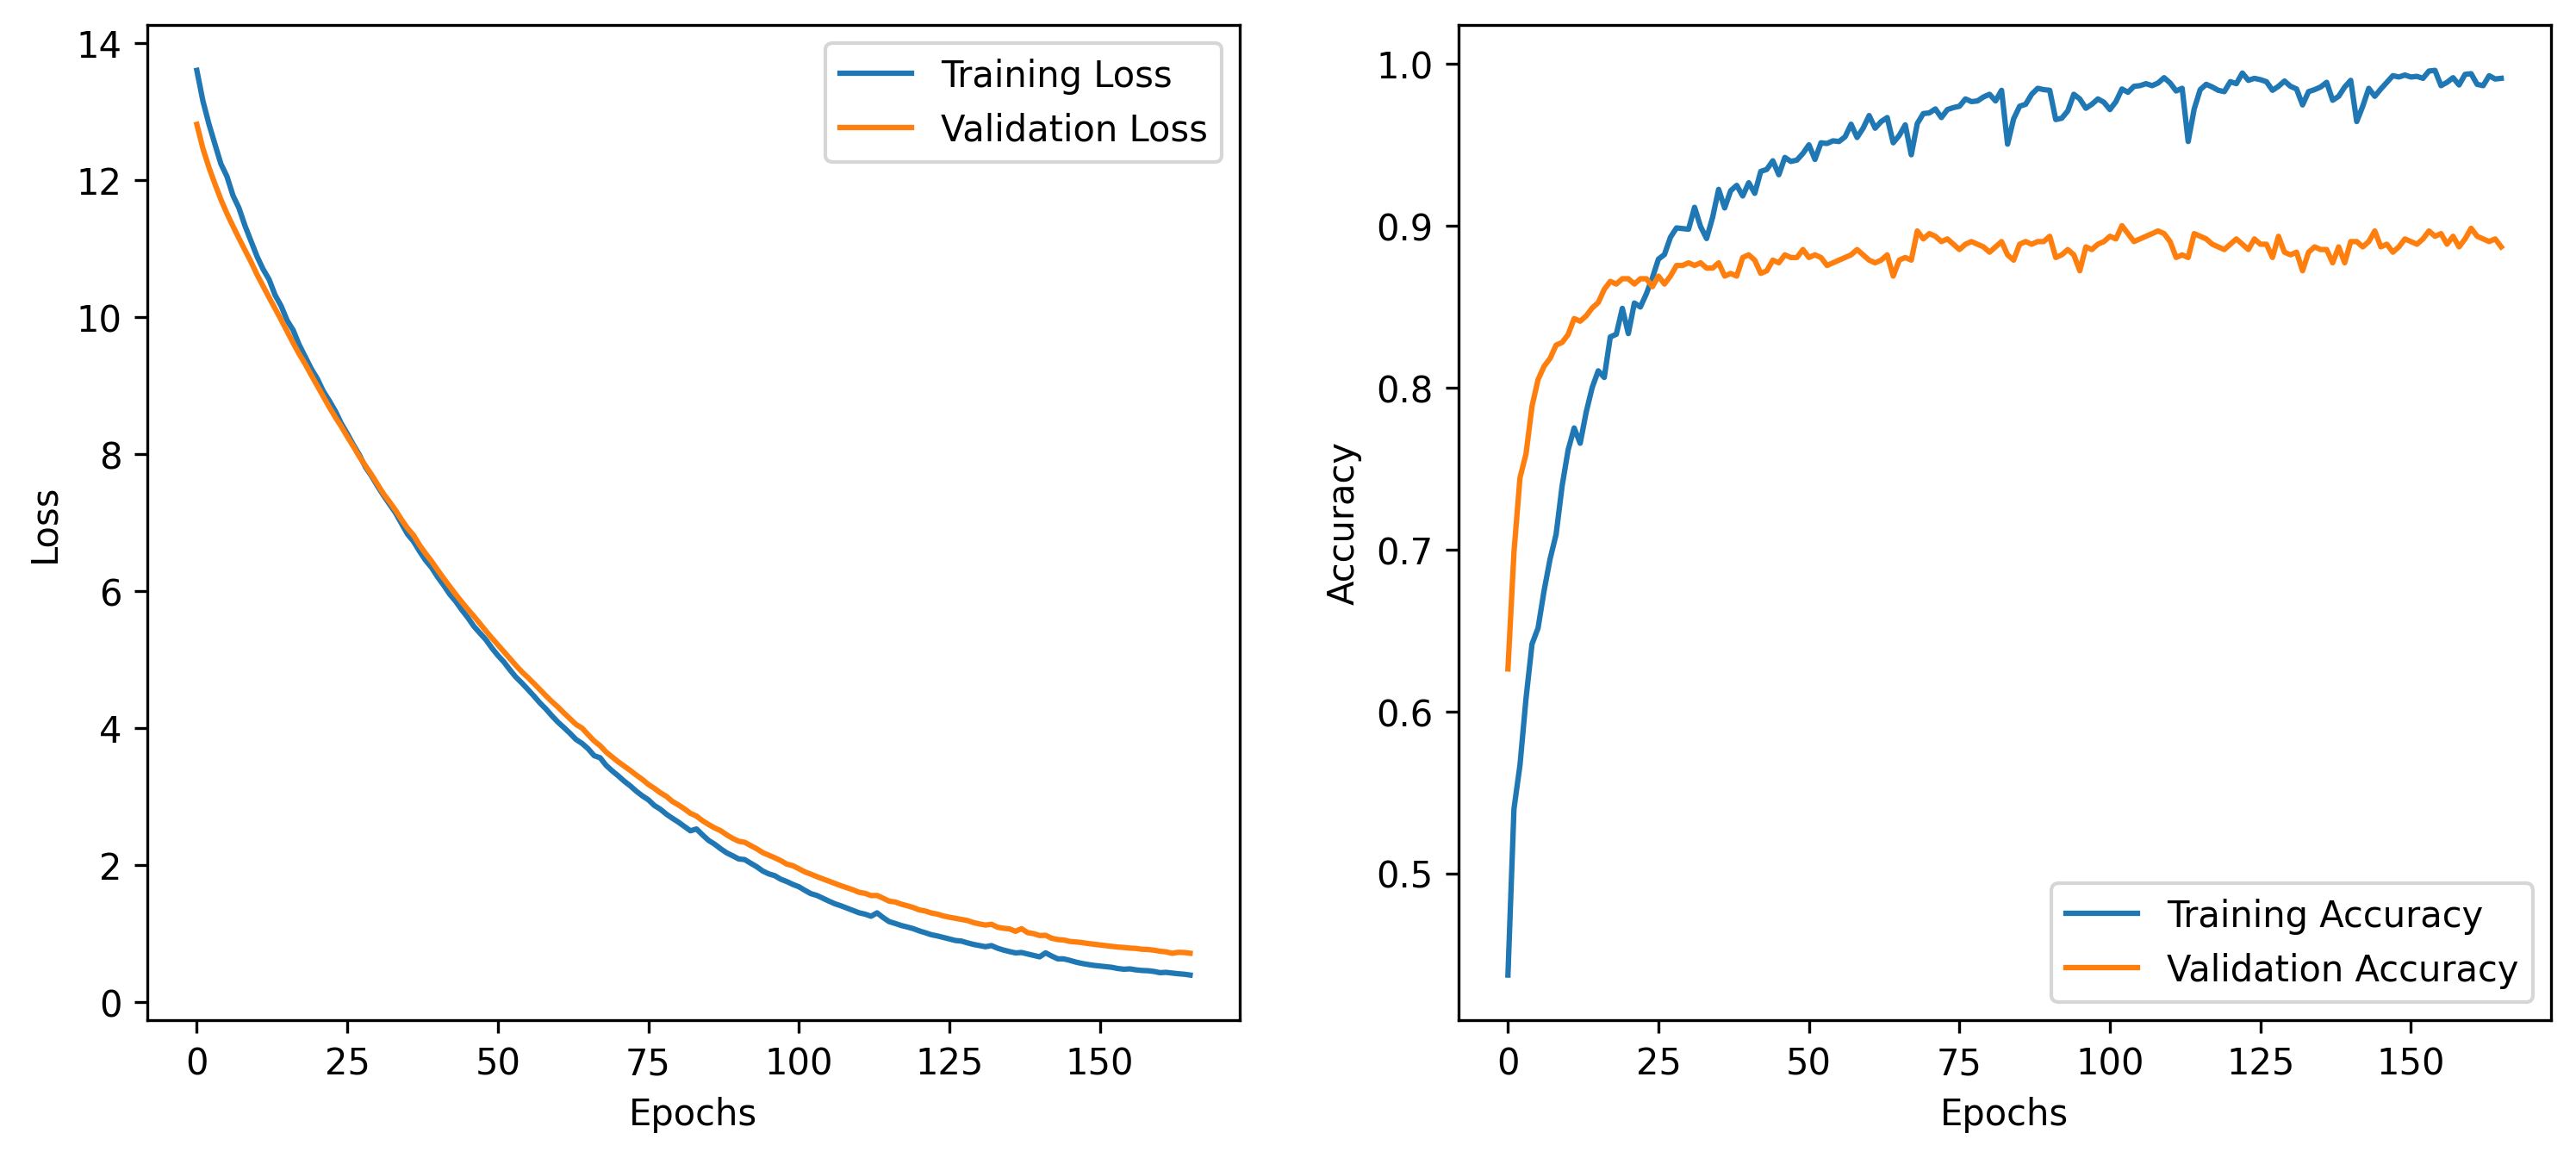

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Dense, Dropout, LayerNormalization, GlobalAveragePooling1D)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

dataset_path = "/kaggle/input/combined_eeg_features.csv"
df = pd.read_csv(dataset_path, header=None)

X = df.iloc[:, :-1].values 
y = df.iloc[:, -1].values  

scaler = StandardScaler()
X = scaler.fit_transform(X)

X = np.expand_dims(X, axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, shuffle=True, random_state=42
)

num_classes = len(np.unique(y))
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

def positional_encoding(length, depth):
    pos = np.arange(length)[:, np.newaxis]
    i = np.arange(depth)[np.newaxis, :]
    angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(depth))
    angle_rads = pos * angle_rates

    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

    return tf.convert_to_tensor(angle_rads, dtype=tf.float32)

class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.6):
        super(TransformerBlock, self).__init__()
        self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.05)),
            Dense(embed_dim, kernel_regularizer=tf.keras.regularizers.l2(0.05))
        ])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs, training=training)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1, training=training)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

def build_transformer(input_shape, num_classes, embed_dim=32, num_heads=2, ff_dim=64, num_blocks=2, dropout_rate=0.6):
    inputs = Input(shape=input_shape)

    positions = positional_encoding(input_shape[0], embed_dim)
    x = Dense(embed_dim, kernel_regularizer=tf.keras.regularizers.l2(0.05))(inputs)
    x += positions 

    for _ in range(num_blocks):
        x = TransformerBlock(embed_dim, num_heads, ff_dim, dropout_rate)(x)

    x = GlobalAveragePooling1D()(x)
    x = Dropout(dropout_rate)(x)
    outputs = Dense(num_classes, activation="softmax", kernel_regularizer=tf.keras.regularizers.l2(0.05))(x)

    return Model(inputs, outputs)

input_shape = (X_train.shape[1], X_train.shape[2]) 
model = build_transformer(input_shape, num_classes)

model.compile(optimizer=Adam(learning_rate=1e-4),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(X_train, y_train,
                    validation_split=0.2,
                    epochs=500,
                    batch_size=128,
                    callbacks=[early_stopping],
                    verbose=1)

y_train_pred = np.argmax(model.predict(X_train), axis=1)
y_test_pred = np.argmax(model.predict(X_test), axis=1)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

from sklearn.metrics import classification_report

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred, digits=4))


conf_matrix = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6,5), dpi=300)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues",
            xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

plt.figure(figsize=(12,5), dpi=300)

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

CV for transformer model


Training on Fold 1/10...



/usr/local/lib/python3.10/dist-packages/keras/src/ops/nn.py:545: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 2, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/ops/nn.py:545: UserWarning: You are using a softmax over axis 3 of a tensor of shape (32, 2, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step
Fold 1 - Training Accuracy: 0.9743
Fold 1 - Testing Accuracy: 0.8924

Training on Fold 2/10...



/usr/local/lib/python3.10/dist-packages/keras/src/ops/nn.py:545: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 2, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/ops/nn.py:545: UserWarning: You are using a softmax over axis 3 of a tensor of shape (32, 2, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step
Fold 2 - Training Accuracy: 0.9734
Fold 2 - Testing Accuracy: 0.8976

Training on Fold 3/10...



...

108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step
Fold 8 - Training Accuracy: 0.9737
Fold 8 - Testing Accuracy: 0.8845

Training on Fold 9/10...



/usr/local/lib/python3.10/dist-packages/keras/src/ops/nn.py:545: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 2, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/ops/nn.py:545: UserWarning: You are using a softmax over axis 3 of a tensor of shape (32, 2, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step
Fold 9 - Training Accuracy: 0.9714
Fold 9 - Testing Accuracy: 0.8842

Training on Fold 10/10...



/usr/local/lib/python3.10/dist-packages/keras/src/ops/nn.py:545: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 2, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/ops/nn.py:545: UserWarning: You are using a softmax over axis 3 of a tensor of shape (32, 2, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step
Fold 10 - Training Accuracy: 0.9700
Fold 10 - Testing Accuracy: 0.8947

----------------------
Mean Training Accuracy: 0.9730 ± 0.0013
Mean Testing Accuracy: 0.8858 ± 0.0106
----------------------


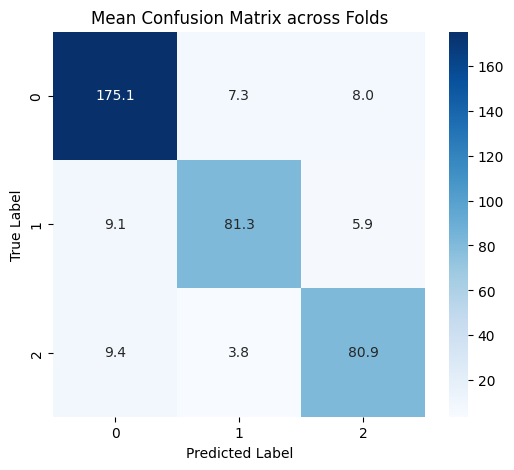

In [4]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Dense, Dropout, LayerNormalization, GlobalAveragePooling1D)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix

dataset_path = "/kaggle/input/eeg-motor-v1/combined_eeg_features.csv"
df = pd.read_csv(dataset_path, header=None)

X = df.iloc[:, :-1].values 
y = df.iloc[:, -1].values 

scaler = StandardScaler()
X = scaler.fit_transform(X)

X = np.expand_dims(X, axis=1)

num_classes = len(np.unique(y))

K = 10  

skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)

train_accuracies = []
test_accuracies = []
history_list = []  
conf_matrices = []  

def positional_encoding(length, depth):
    pos = np.arange(length)[:, np.newaxis]
    i = np.arange(depth)[np.newaxis, :]
    angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(depth))
    angle_rads = pos * angle_rates

    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

    return tf.convert_to_tensor(angle_rads, dtype=tf.float32)

class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.6):
        super(TransformerBlock, self).__init__()
        self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation="relu", kernel_regularizer=l2(0.05)),
            Dense(embed_dim, kernel_regularizer=l2(0.05))
        ])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs, training=training)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1, training=training)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

def build_transformer(input_shape, num_classes, embed_dim=32, num_heads=2, ff_dim=64, num_blocks=2, dropout_rate=0.6):
    inputs = Input(shape=input_shape)

    positions = positional_encoding(input_shape[0], embed_dim)
    x = Dense(embed_dim, kernel_regularizer=l2(0.05))(inputs)  
    x += positions  

    for _ in range(num_blocks):
        x = TransformerBlock(embed_dim, num_heads, ff_dim, dropout_rate)(x)

    x = GlobalAveragePooling1D()(x)
    x = Dropout(dropout_rate)(x)
    outputs = Dense(num_classes, activation="softmax", kernel_regularizer=l2(0.05))(x)

    return Model(inputs, outputs)

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    print(f"\nTraining on Fold {fold + 1}/{K}...\n")
    
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    input_shape = (X_train.shape[1], X_train.shape[2])
    model = build_transformer(input_shape, num_classes)

    model.compile(optimizer=Adam(learning_rate=1e-4),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])

    early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=500,
        batch_size=128,
        callbacks=[early_stopping],
        verbose=0
    )

    history_list.append(history.history)

    y_train_pred = np.argmax(model.predict(X_train), axis=1)
    y_test_pred = np.argmax(model.predict(X_test), axis=1)

    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    print(f"Fold {fold + 1} - Training Accuracy: {train_accuracy:.4f}")
    print(f"Fold {fold + 1} - Testing Accuracy: {test_accuracy:.4f}")

    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

    conf_matrices.append(confusion_matrix(y_test, y_test_pred))

mean_train_accuracy = np.mean(train_accuracies)
std_train_accuracy = np.std(train_accuracies)

mean_test_accuracy = np.mean(test_accuracies)
std_test_accuracy = np.std(test_accuracies)

print("\n----------------------")
print(f"Mean Training Accuracy: {mean_train_accuracy:.4f} ± {std_train_accuracy:.4f}")
print(f"Mean Testing Accuracy: {mean_test_accuracy:.4f} ± {std_test_accuracy:.4f}")
print("----------------------")

mean_conf_matrix = np.mean(conf_matrices, axis=0)

plt.figure(figsize=(6,5))
sns.heatmap(mean_conf_matrix, annot=True, fmt='.1f', cmap="Blues",
            xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Mean Confusion Matrix across Folds")
plt.show()


EEGNet

Epoch 1/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 187ms/step - accuracy: 0.3830 - loss: 1.1243 - val_accuracy: 0.4508 - val_loss: 1.0964
Epoch 2/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4188 - loss: 1.0831 - val_accuracy: 0.4918 - val_loss: 1.0945
Epoch 3/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4661 - loss: 1.0740 - val_accuracy: 0.5033 - val_loss: 1.0922
Epoch 4/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4756 - loss: 1.0685 - val_accuracy: 0.5066 - val_loss: 1.0898
Epoch 5/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4838 - loss: 1.0630 - val_accuracy: 0.5033 - val_loss: 1.0870
Epoch 6/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5080 - loss: 1.0572 - val_accuracy: 0.5131 - val_loss: 1.0837
Epoch 7/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5358 - loss: 1.0473 - val_accuracy: 0.5197 - val_loss: 1.0797
Epoch 8/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5097 - loss: 1.0438 - val_accuracy: 0.5279 

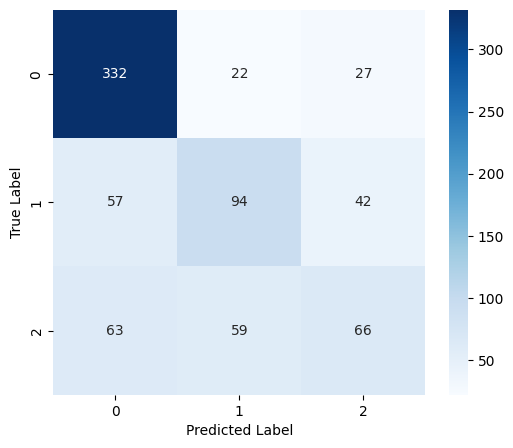

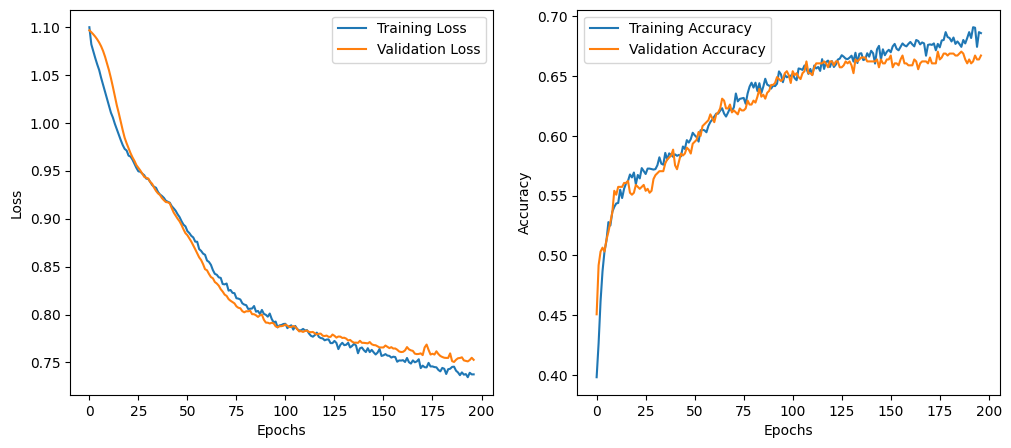

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Dense, Dropout, Flatten, Conv2D, DepthwiseConv2D, SeparableConv2D,
                                     BatchNormalization, Activation, AveragePooling2D, Lambda)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import classification_report


dataset_path = "/kaggle/input/combined_eeg_features.csv"
df = pd.read_csv(dataset_path, header=None)

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values 

scaler = StandardScaler()
X = scaler.fit_transform(X)

channels = 19 
time_points = X.shape[1] // channels
X = X.reshape(-1, channels, time_points, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, shuffle=True, random_state=42
)

num_classes = len(np.unique(y))
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

def EEGNet(nb_classes, Chans=19, Samples=200, dropoutRate=0.1, kernLength=64, F1=8, D=2, F2=16):
    input1 = Input(shape=(Chans, Samples, 1))

    block1 = Conv2D(F1, (1, kernLength), padding='same', use_bias=False)(input1)
    block1 = BatchNormalization()(block1)
    block1 = DepthwiseConv2D((Chans, 1), use_bias=False, depth_multiplier=D,
                              depthwise_constraint=tf.keras.constraints.MaxNorm(1.))(block1)
    block1 = BatchNormalization()(block1)
    block1 = Activation('elu')(block1)
    block1 = AveragePooling2D((1, 4))(block1)
    block1 = Dropout(dropoutRate)(block1)

    block2 = SeparableConv2D(F2, (1, 16), use_bias=False, padding='same')(block1)
    block2 = BatchNormalization()(block2)
    block2 = Activation('elu')(block2)
    block2 = AveragePooling2D((1, 8))(block2)
    block2 = Dropout(dropoutRate)(block2)

    flatten = Flatten(name='flatten')(block2)
    dense = Dense(nb_classes, name='dense', kernel_constraint=tf.keras.constraints.MaxNorm(0.25))(flatten)
    softmax = Activation('softmax', name='softmax')(dense)

    return Model(inputs=input1, outputs=softmax)

model = EEGNet(nb_classes=num_classes, Chans=channels, Samples=time_points)
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(X_train, y_train,
                    validation_split=0.2,
                    epochs=250,
                    batch_size=128,
                    callbacks=[early_stopping],
                    verbose=1)

y_train_pred = np.argmax(model.predict(X_train), axis=1)
y_test_pred = np.argmax(model.predict(X_test), axis=1)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"📌 Training Accuracy: {train_accuracy:.4f}")
print(f"📌 Testing Accuracy: {test_accuracy:.4f}")

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred, digits=4))


conf_matrix = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues",
            xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

cv for EEGNeT


🔄 Training on Fold 1/10...

108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
✅ Fold 1 - Training Accuracy: 0.7333
✅ Fold 1 - Testing Accuracy: 0.7192

🔄 Training on Fold 2/10...

108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
✅ Fold 2 - Training Accuracy: 0.6898
✅ Fold 2 - Testing Accuracy: 0.6745

🔄 Training on Fold 3/10...

108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
✅ Fold 3 - Training Accuracy: 0.7123
✅ Fold 3 - Testing Accuracy: 0.6719

🔄 Training on Fold 4/10...

108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
✅ Fold 4 - Training Accuracy: 0.7207
✅ Fold 4 - Testing Accuracy: 0.6798

🔄 Training on Fold 5/10...

108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
✅ Fold 5 - Training Accuracy: 0.7423
✅ Fold 5 - Testing Accuracy: 0.6772

🔄 Training on Fold 6/10...

108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
12/12 ━━━━━━━━━

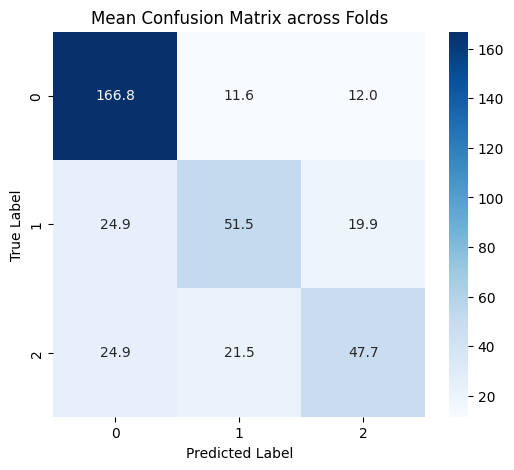

In [11]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Dense, Dropout, Flatten, Conv2D, DepthwiseConv2D, SeparableConv2D,
                                     BatchNormalization, Activation, AveragePooling2D)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix

dataset_path = "/kaggle/input/eeg-motor-v1/combined_eeg_features.csv"
df = pd.read_csv(dataset_path, header=None)

X = df.iloc[:, :-1].values 
y = df.iloc[:, -1].values  

scaler = StandardScaler()
X = scaler.fit_transform(X)

channels = 19
time_points = X.shape[1] // channels 
X = X.reshape(-1, channels, time_points, 1)

num_classes = len(np.unique(y))

K = 10  

skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)

train_accuracies = []
test_accuracies = []
history_list = []  
conf_matrices = []  

def EEGNet(nb_classes, Chans=19, Samples=200, dropoutRate=0.1, kernLength=64, F1=8, D=2, F2=16):
    input1 = Input(shape=(Chans, Samples, 1))

    block1 = Conv2D(F1, (1, kernLength), padding='same', use_bias=False)(input1)
    block1 = BatchNormalization()(block1)
    block1 = DepthwiseConv2D((Chans, 1), use_bias=False, depth_multiplier=D,
                              depthwise_constraint=tf.keras.constraints.MaxNorm(1.))(block1)
    block1 = BatchNormalization()(block1)
    block1 = Activation('elu')(block1)
    block1 = AveragePooling2D((1, 4))(block1)
    block1 = Dropout(dropoutRate)(block1)

    block2 = SeparableConv2D(F2, (1, 16), use_bias=False, padding='same')(block1)
    block2 = BatchNormalization()(block2)
    block2 = Activation('elu')(block2)
    block2 = AveragePooling2D((1, 8))(block2)
    block2 = Dropout(dropoutRate)(block2)

    flatten = Flatten(name='flatten')(block2)
    dense = Dense(nb_classes, name='dense', kernel_constraint=tf.keras.constraints.MaxNorm(0.25))(flatten)
    softmax = Activation('softmax', name='softmax')(dense)

    return Model(inputs=input1, outputs=softmax)

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    print(f"\n🔄 Training on Fold {fold + 1}/{K}...\n")
    
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = EEGNet(nb_classes=num_classes, Chans=channels, Samples=time_points)

    model.compile(optimizer=Adam(learning_rate=1e-4),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])

    early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=250,
        batch_size=128,
        callbacks=[early_stopping],
        verbose=0 
    )

    history_list.append(history.history)

    y_train_pred = np.argmax(model.predict(X_train), axis=1)
    y_test_pred = np.argmax(model.predict(X_test), axis=1)

    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    print(f"✅ Fold {fold + 1} - Training Accuracy: {train_accuracy:.4f}")
    print(f"✅ Fold {fold + 1} - Testing Accuracy: {test_accuracy:.4f}")

    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

    conf_matrices.append(confusion_matrix(y_test, y_test_pred))

mean_train_accuracy = np.mean(train_accuracies)
std_train_accuracy = np.std(train_accuracies)

mean_test_accuracy = np.mean(test_accuracies)
std_test_accuracy = np.std(test_accuracies)

print("\n📊 ----------------------")
print(f"📌 Mean Training Accuracy: {mean_train_accuracy:.4f} ± {std_train_accuracy:.4f}")
print(f"📌 Mean Testing Accuracy: {mean_test_accuracy:.4f} ± {std_test_accuracy:.4f}")
print("----------------------")

mean_conf_matrix = np.mean(conf_matrices, axis=0)

plt.figure(figsize=(6,5))
sns.heatmap(mean_conf_matrix, annot=True, fmt='.1f', cmap="Blues",
            xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Mean Confusion Matrix across Folds")
plt.show()

XGBoost

Training Accuracy: 0.9905
Testing Accuracy: 0.8635

Classification Report (Test Set):
              precision    recall  f1-score   support

         0.0     0.8426    0.9554    0.8954       381
         1.0     0.8902    0.7979    0.8415       193
         2.0     0.8917    0.7447    0.8116       188

    accuracy                         0.8635       762
   macro avg     0.8748    0.8327    0.8495       762
weighted avg     0.8668    0.8635    0.8611       762



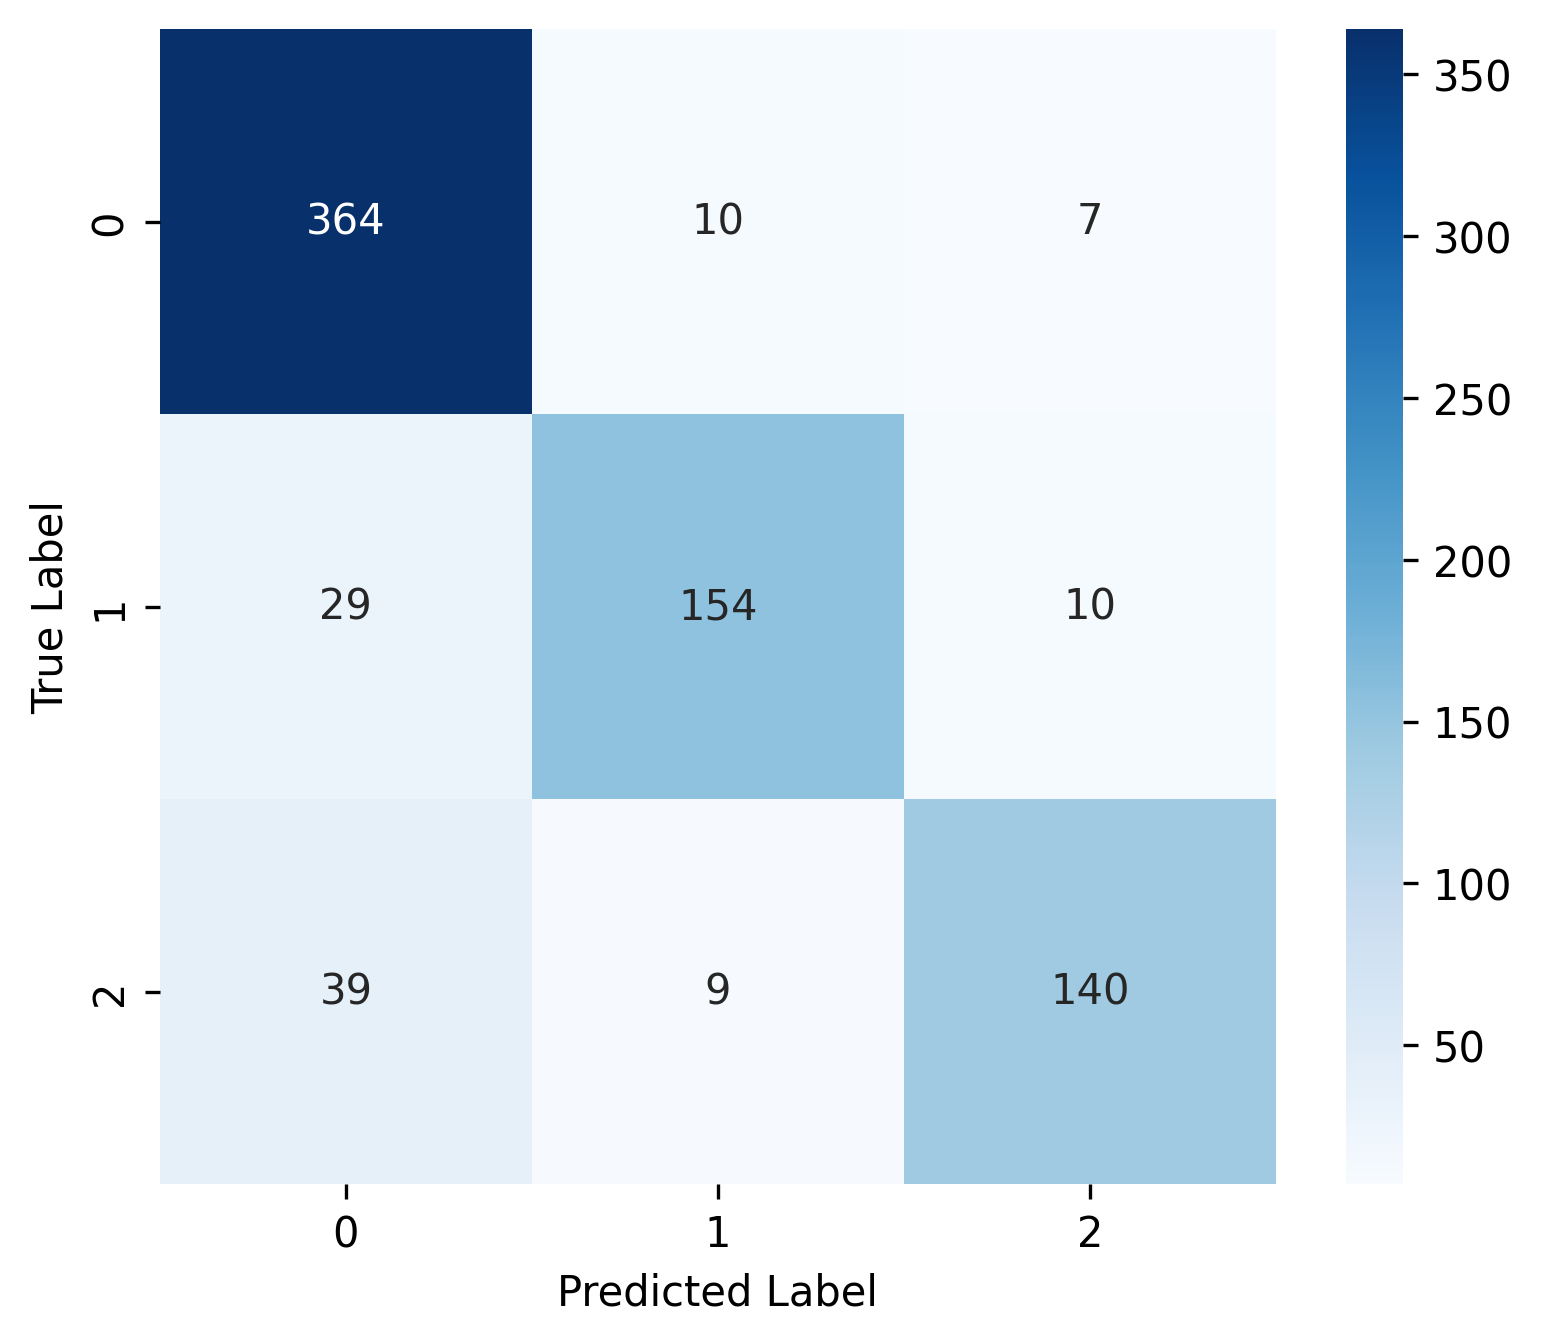

<Figure size 3000x1500 with 0 Axes>

<Figure size 3000x1500 with 0 Axes>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import classification_report


dataset_path = "/kaggle/input/combined_eeg_features.csv"
df = pd.read_csv(dataset_path, header=None)

X = df.iloc[:, :-1].values  
y = df.iloc[:, -1].values 

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, shuffle=True, random_state=42
)

xgb_model = xgb.XGBClassifier(
    objective="multi:softmax",  
    num_class=len(np.unique(y)), 
    learning_rate=0.01,
    n_estimators=300, 
    subsample=0.8, 
    colsample_bytree=0.8, 
    random_state=42
)


xgb_model.fit(X_train, y_train)


y_train_pred = xgb_model.predict(X_train)
y_test_pred = xgb_model.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")


print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred, digits=4))


conf_matrix = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6,5), dpi=300)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues",
            xticklabels=range(len(np.unique(y))), 
            yticklabels=range(len(np.unique(y))))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

plt.figure(figsize=(10, 5), dpi=300)
xgb.plot_importance(xgb_model, importance_type="weight", max_num_features=15)
plt.title("Top 15 Feature Importances - XGBoost")
plt.show()

Training Fold 1/10...
Fold 1 Accuracy: 0.8556
Training Fold 2/10...
Fold 2 Accuracy: 0.8609
Training Fold 3/10...
Fold 3 Accuracy: 0.8635
Training Fold 4/10...
Fold 4 Accuracy: 0.8294
Training Fold 5/10...
Fold 5 Accuracy: 0.8425
Training Fold 6/10...
Fold 6 Accuracy: 0.8556
Training Fold 7/10...
Fold 7 Accuracy: 0.8845
Training Fold 8/10...
Fold 8 Accuracy: 0.8241
Training Fold 9/10...
Fold 9 Accuracy: 0.8316
Training Fold 10/10...
Fold 10 Accuracy: 0.8526

Mean Accuracy: 0.8500
Standard Deviation: 0.0175


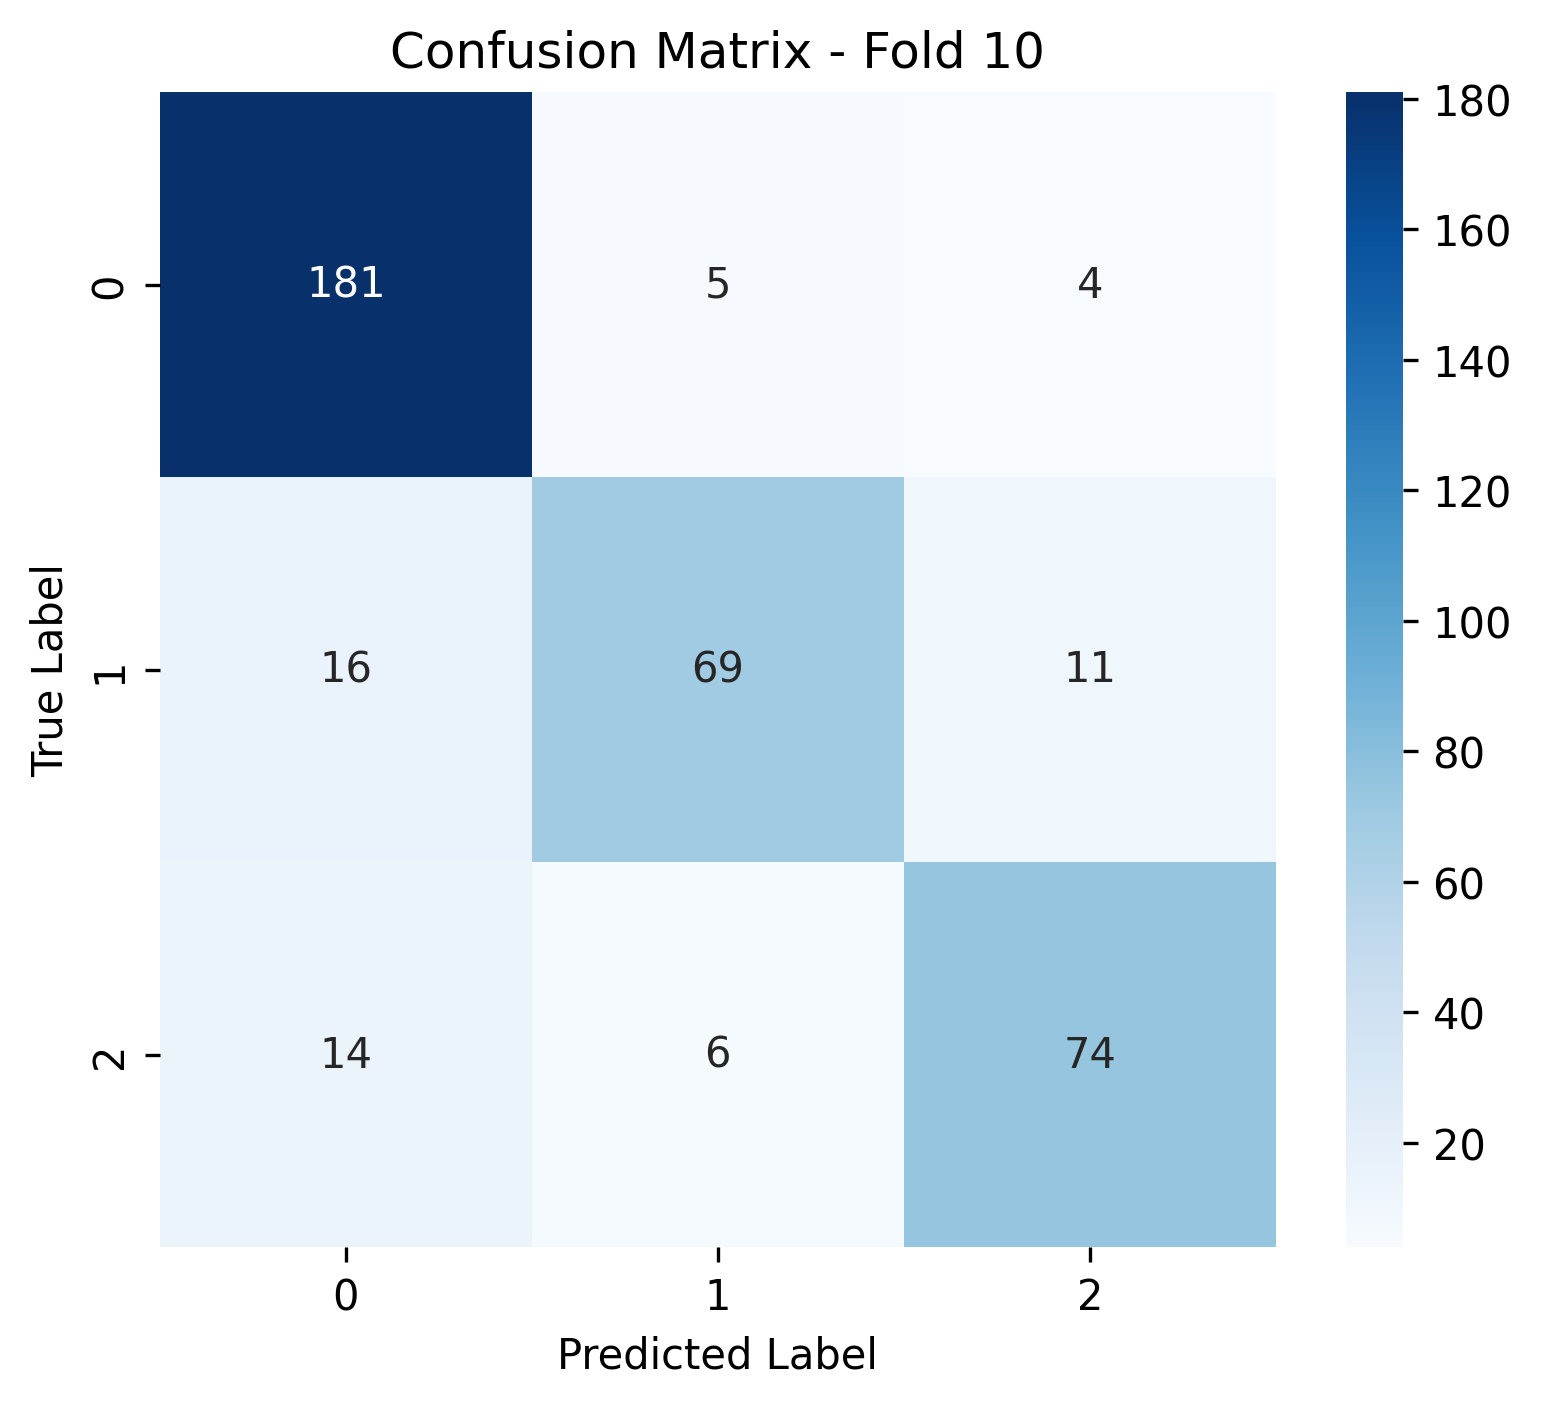

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix


dataset_path = "/kaggle/input/eeg-motor-v1/combined_eeg_features.csv"
df = pd.read_csv(dataset_path, header=None)

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

xgb_params = {
    "objective": "multi:softmax",
    "num_class": len(np.unique(y)),
    "max_depth": 6,
    "learning_rate": 0.01,
    "n_estimators": 300,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42
}


kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
fold_accuracies = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X, y)):
    print(f"Training Fold {fold+1}/10...")
    
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = xgb.XGBClassifier(**xgb_params)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    fold_accuracies.append(accuracy)
    
    print(f"Fold {fold+1} Accuracy: {accuracy:.4f}")

mean_accuracy = np.mean(fold_accuracies)
std_accuracy = np.std(fold_accuracies)

print(f"\nMean Accuracy: {mean_accuracy:.4f}")
print(f"Standard Deviation: {std_accuracy:.4f}")

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5), dpi=300)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues",
            xticklabels=range(len(np.unique(y))), 
            yticklabels=range(len(np.unique(y))))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Confusion Matrix - Fold {fold+1}")
plt.show()